# ColabFold

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.onekg as og

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import glob

import src.colabfold as cf

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## Create MSA for each haplotype

In [ ]:
haplotype_msas = cf.create_haplotype_msas(template_msa="~/projects/data/ProteinGym/subs/refseq-BRCA1-NM_007294.3.a2m", 
                                          haplotypes_fasta="~/projects/data/colabfold/ENST00000357654/ENST00000357654.fasta",  
                                        #   output_dir="~/projects/data/colabfold/ENST00000357654/af2_sameMSA",
                                          description_prefix="1000_Genomes_on_GRCh38-Haplosaurus-")
haplotype_msas[:10]

Processing haplotype sequences: 100%|██████████| 109/109 [00:00<00:00, 418.11it/s]


['/tmp/tmp3aj_s_p4/ENSP00000350283_REF.a3m',
 '/tmp/tmp3aj_s_p4/ENSP00000350283_871P_L_1038E_G_1183K_R_1613S_G.a3m',
 '/tmp/tmp3aj_s_p4/ENSP00000350283_871P_L.a3m',
 '/tmp/tmp3aj_s_p4/ENSP00000350283_693D_N_871P_L_1038E_G_1183K_R_1613S_G.a3m',
 '/tmp/tmp3aj_s_p4/ENSP00000350283_356Q_R.a3m',
 '/tmp/tmp3aj_s_p4/ENSP00000350283_871P_L_1038E_G_1183K_R_1613S_G_1652M_I.a3m',
 '/tmp/tmp3aj_s_p4/ENSP00000350283_871P_L_1140S_G.a3m',
 '/tmp/tmp3aj_s_p4/ENSP00000350283_820K_E_871P_L_1183K_R_1613S_G.a3m',
 '/tmp/tmp3aj_s_p4/ENSP00000350283_1040S_N.a3m',
 '/tmp/tmp3aj_s_p4/ENSP00000350283_186S_Y_871P_L_1183K_R_1613S_G.a3m']

## Import PDB files

In [91]:
base_dir = os.path.expanduser("~/projects/data/colabfold")
def search_files(base_dir = os.path.expanduser("~/projects/data/colabfold"),
                 tx_id = "ENST00000357654",
                 subdir = "af2_sameMSA",
                 suffix = ".pdb",
                 model_number = 1):
    
    pdb_files = glob.glob(os.path.join(base_dir,
                                    tx_id,
                                    "**",
                                    #    "*_unrelaxed_rank_001_*.pdb"
                                    f"{subdir}/*_unrelaxed_*_model_{model_number}_*{suffix}"
                                    ),
                        recursive=True)
    print(len(pdb_files),"PDB files found") 
    return pdb_files

In [95]:
pdb_files = search_files(tx_id = "ENST00000357654",
                         suffix = ".pdb",
                         model_number = 1)

2 PDB files found


### import 2D contact maps

In [88]:
contact_maps = {}
for pdb_file in tqdm(pdb_files):
    structure = cf.import_pdb(pdb_file)
    contact_maps[pdb_file] = cf.get_contact_map(structure)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00,  4.10it/s]


### Contact map interpolation

Creating animation between:
Map 1: ENSP00000350283_REF_unrelaxed_rank_002_alphafold2_ptm_model_1_seed_000.pdb
Map 2: ENSP00000350283_871P_L_unrelaxed_rank_002_alphafold2_ptm_model_1_seed_000.pdb


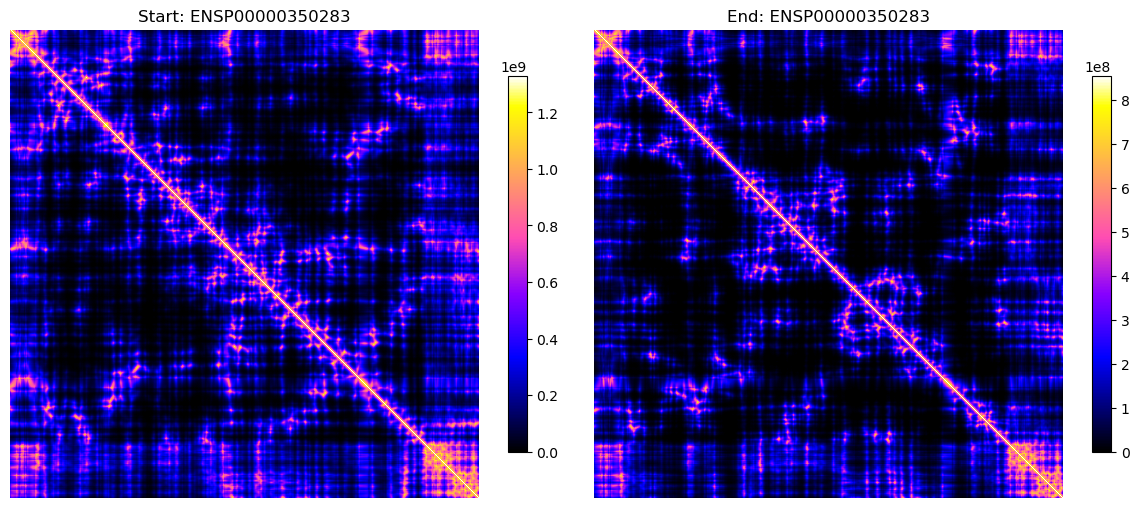

Animation created! Check 'contact_map_transition.gif' for the smooth transition.


In [ ]:
# Create smooth transition animation between two contact maps
if len(contact_maps) >= 2:
    map_names = list(contact_maps.keys())
    map1_name = map_names[0]
    map2_name = map_names[1]
    
    print(f"Creating animation between:")
    print(f"Map 1: {os.path.basename(map1_name)}")
    print(f"Map 2: {os.path.basename(map2_name)}")
    
    # Create the animation
    animation_frames = cf.animate_contact_map_interpolation(
        contact_maps[map1_name], 
        contact_maps[map2_name], 
        num_frames=20,
        pow=4,
        output_path="contact_map_transition.gif"
    )
    
    # Display the first and last frames for comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Original maps
    im1 = ax1.imshow(contact_maps[map1_name]**4, cmap='gnuplot2', interpolation='nearest')
    ax1.set_title(f'Start: {os.path.basename(map1_name).split("_")[0]}')
    ax1.axis('off')
    plt.colorbar(im1, ax=ax1, shrink=0.8)
    
    im2 = ax2.imshow(contact_maps[map2_name]**4, cmap='gnuplot2', interpolation='nearest')
    ax2.set_title(f'End: {os.path.basename(map2_name).split("_")[0]}')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, shrink=0.8)
    
    plt.tight_layout()
    plt.show()
    
    print("Animation created! Check 'contact_map_transition.gif' for the smooth transition.")

else:
    print("Need at least 2 contact maps to create an animation.")



### Contact map variation: grid

100%|██████████| 2/2 [00:00<00:00, 25.41it/s]


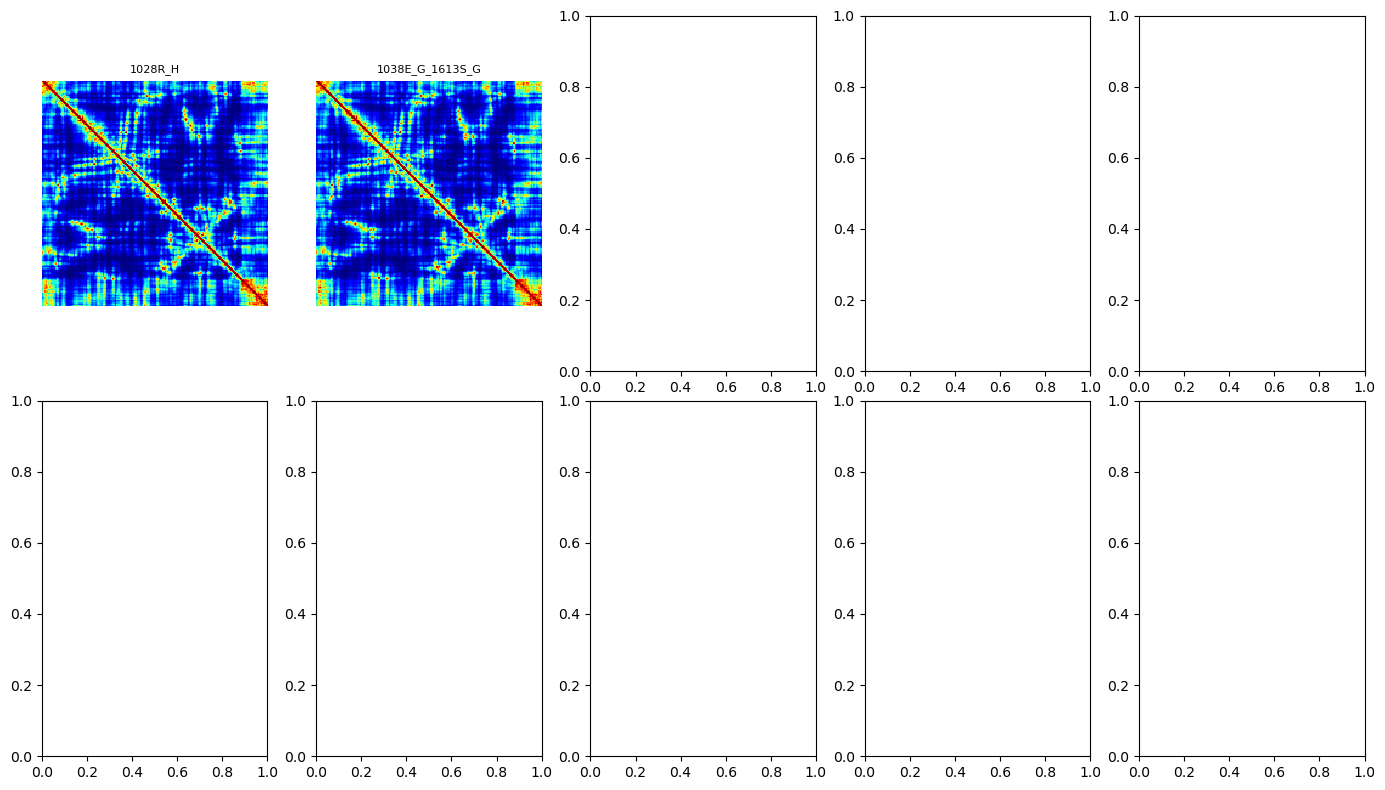

In [89]:
fig, axes = plt.subplots(2, 5, figsize=(14, 8))
axes = axes.flatten()

for i, (name, contact_map) in enumerate(tqdm(list(contact_maps.items())[:10])):
    ### Bin the matrix   
    bin_size = 10 
    log_after_bin = False
    pow = 4
    cmap = "jet" 
    
    contact_map_binned = cf.bin_matrix(X=contact_map**pow, 
                                       bin_size=bin_size)
    n_bins = contact_map_binned.shape[0]
     
    # Create the plot in the grid
    im = axes[i].imshow(contact_map_binned, 
                        cmap=cmap, 
                        interpolation="nearest")
    protein_id = os.path.basename(name).split("_unrelaxed")[0].split("_")[0]
    haplotype_id = os.path.basename(name).split("_unrelaxed")[0].replace(protein_id+"_","")
    axes[i].set_title(f"{haplotype_id}", fontsize=8)
    axes[i].axis('off')

plt.tight_layout(h_pad=0.0001, w_pad=0.1)
plt.show()

### Contact map variation: GIF

In [90]:
frames = cf.animate_contact_maps_variation(contact_maps, n_frames=None)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00,  9.65it/s]

GIF saved as 'results/plots/contact_maps_animation.gif'


## Plot high-variance regions

Variance map shape: (1863, 1863)
Variance range: 29.566635 to 1841.182861


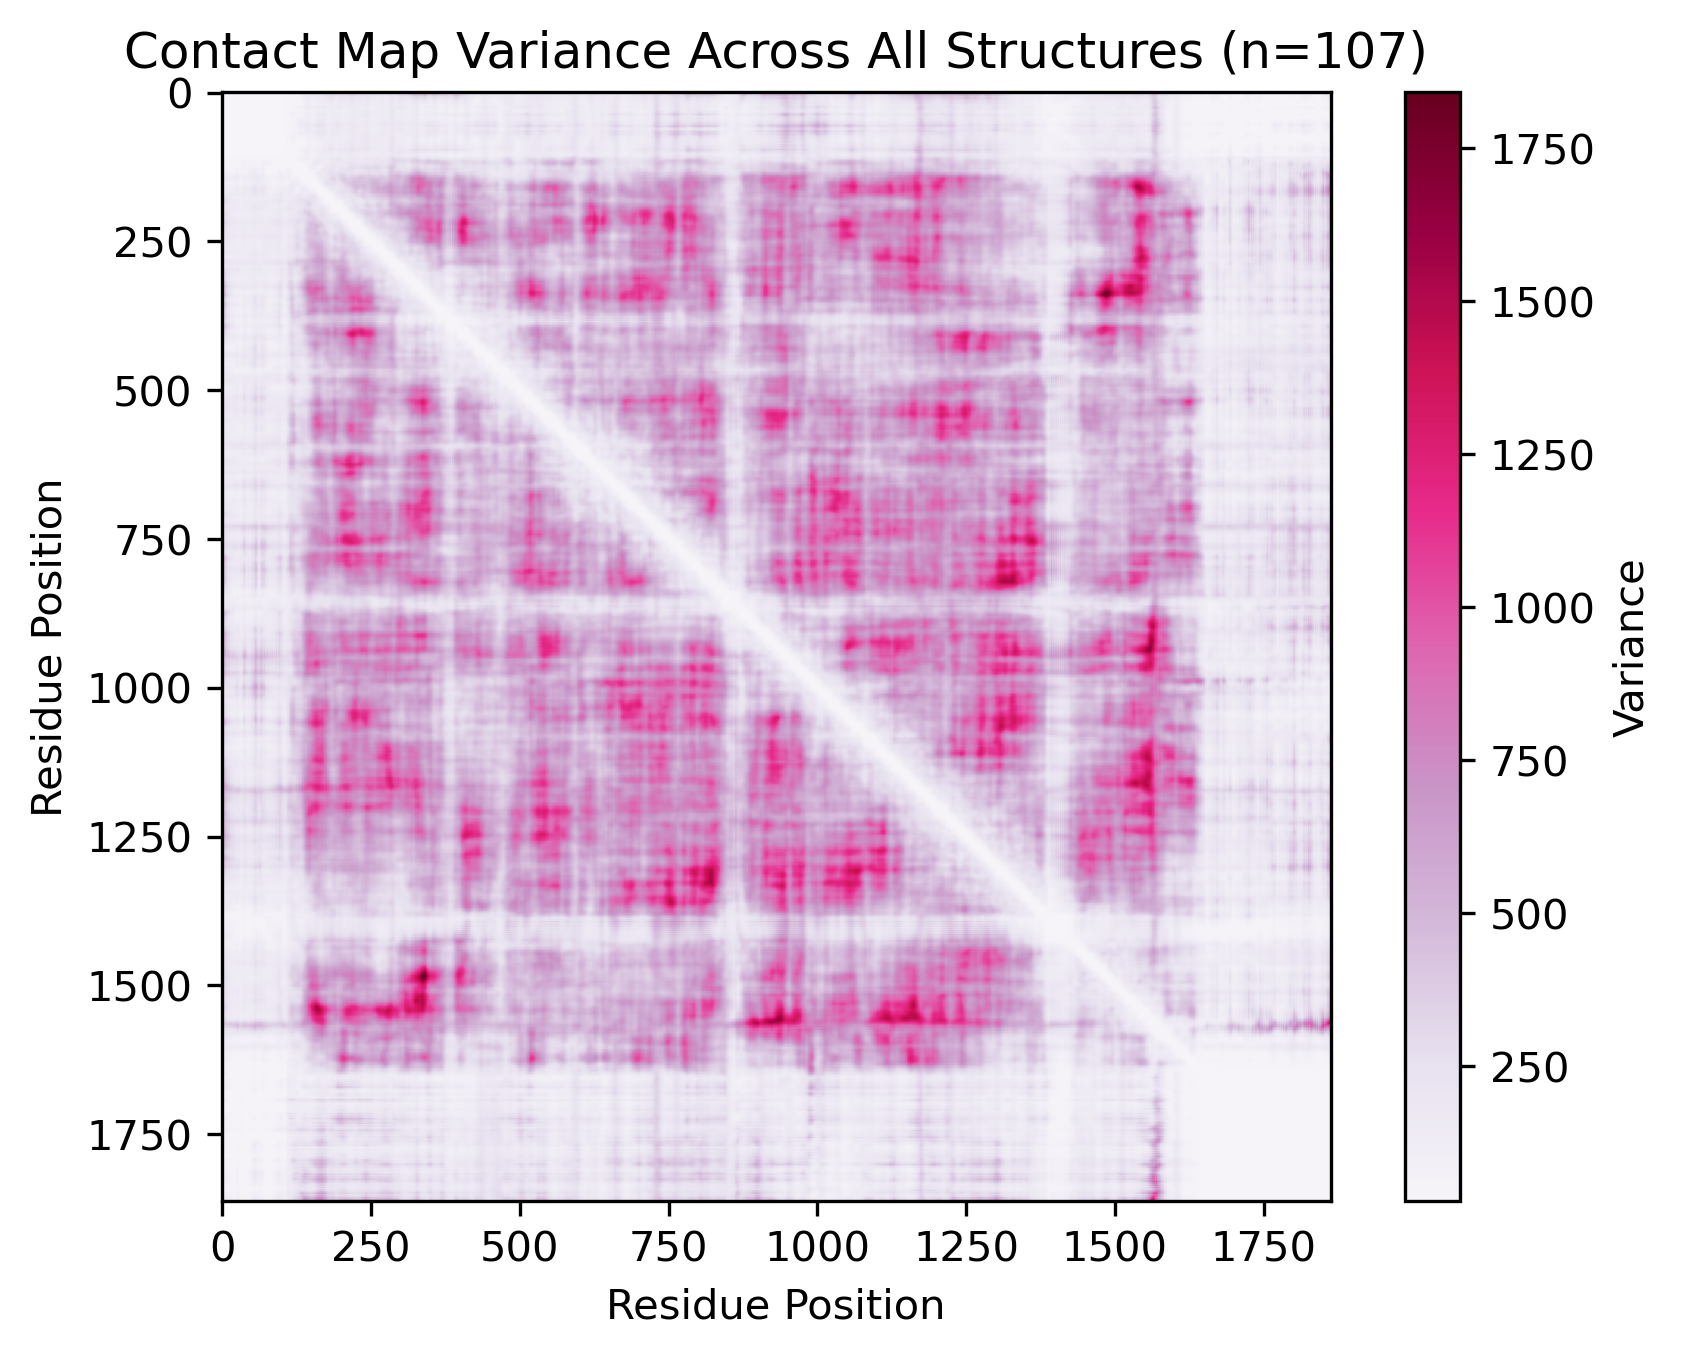

Top 10% variance threshold: 824.986755
Number of high-variance positions: 347076


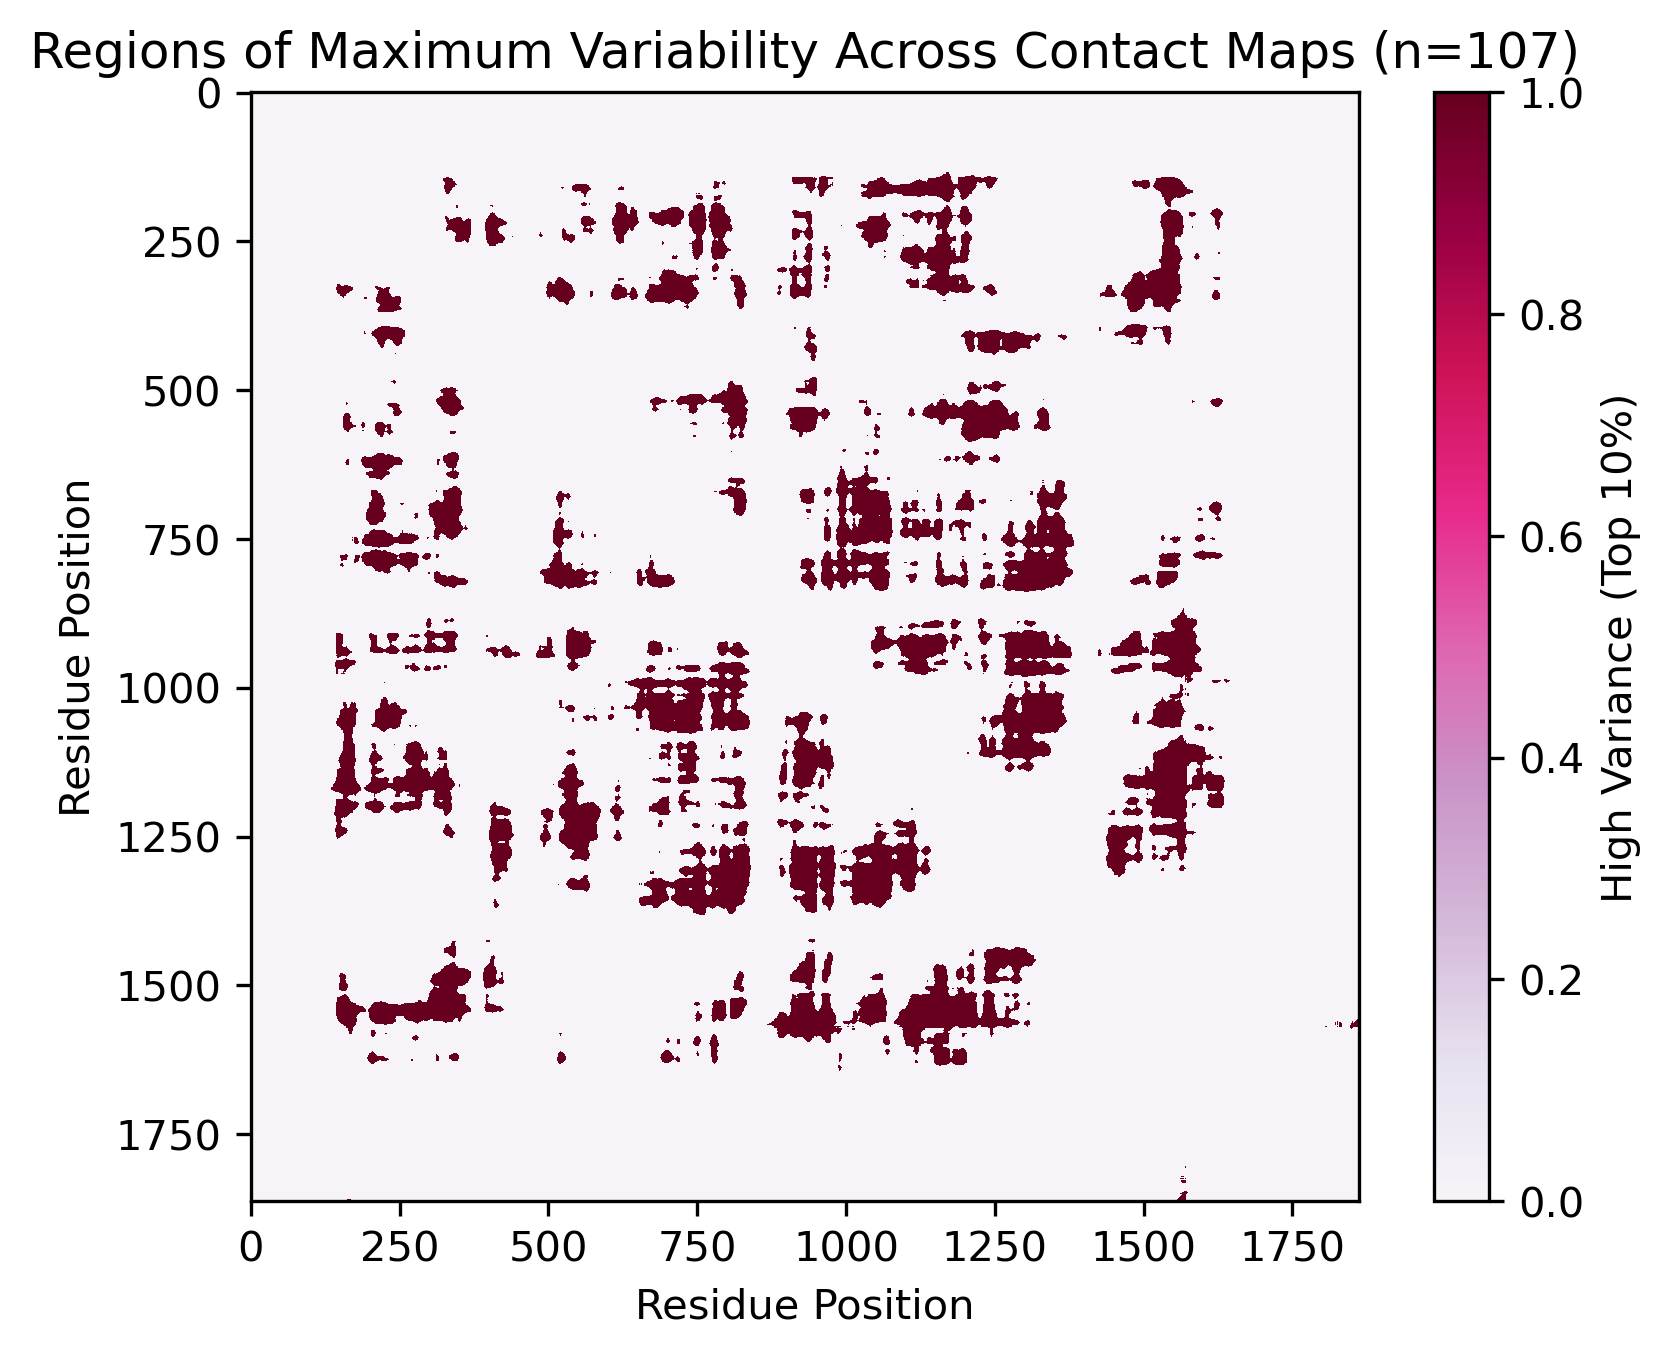

Coordinates of highest variance regions:
  Position (135, 1168): variance = 825.566284
  Position (135, 1169): variance = 839.493896
  Position (135, 1170): variance = 843.441345
  Position (135, 1171): variance = 836.863098
  Position (136, 1167): variance = 841.161133
  Position (136, 1168): variance = 858.746704
  Position (136, 1169): variance = 870.907654
  Position (136, 1170): variance = 873.200439
  Position (136, 1171): variance = 864.043579
  Position (136, 1172): variance = 848.552368


In [4]:
# Compute variance across all contact maps to find maximally variable regions
import numpy as np

# Stack all contact maps into a 3D array
contact_maps_array = np.stack(list(contact_maps.values()))

# Compute variance across the first dimension (across all contact maps)
variance_map = np.var(contact_maps_array, axis=0)

print(f"Variance map shape: {variance_map.shape}")
print(f"Variance range: {np.min(variance_map):.6f} to {np.max(variance_map):.6f}")
figsize=None
dpi=300

# Plot the variance map to visualize regions of high variability
plt.figure(figsize=figsize, dpi=dpi)
plt.imshow(variance_map, cmap='PuRd', interpolation='nearest')
plt.colorbar(label='Variance')
plt.title(f'Contact Map Variance Across All Structures (n={contact_maps_array.shape[0]})')
plt.xlabel('Residue Position')
plt.ylabel('Residue Position')
plt.show()

# Find the regions with highest variance
# Get the top 10% of variance values
variance_threshold = np.percentile(variance_map, 90)
high_variance_mask = variance_map > variance_threshold

print(f"Top 10% variance threshold: {variance_threshold:.6f}")
print(f"Number of high-variance positions: {np.sum(high_variance_mask)}")

# Plot high variance regions
plt.figure(figsize=figsize, dpi=dpi)
plt.imshow(high_variance_mask, cmap='PuRd', interpolation='nearest')
plt.colorbar(label='High Variance (Top 10%)')
plt.title(f'Regions of Maximum Variability Across Contact Maps (n={contact_maps_array.shape[0]})')
plt.xlabel('Residue Position')
plt.ylabel('Residue Position')
plt.show()


# Optional: Get coordinates of highest variance positions
high_variance_coords = np.where(high_variance_mask)
print(f"Coordinates of highest variance regions:")
for i in range(min(10, len(high_variance_coords[0]))):
    row, col = high_variance_coords[0][i], high_variance_coords[1][i]
    variance_value = variance_map[row, col]
    print(f"  Position ({row}, {col}): variance = {variance_value:.6f}")


### Get Predicted Aligned Error (PAE)

📘 What is PAE?
- predicted_aligned_error[i, j] = expected positional error in Ångströms at residue i when the predicted and true structures are aligned on residue j

- Asymmetric matrix: PAE[i,j] ≠ PAE[j,i]

- Useful for identifying flexible domains or low-confidence interdomain contacts

In [ ]:
# Read PAE from JSON file
import json

glob.glob("ENSP00000350283_REF_predicted_aligned_error_v1.json")
base_dir = os.path.expanduser("~/projects/data/colabfold")
pae_files = glob.glob(os.path.join(base_dir,
                                   "ENST00000357654",
                                   "**", 
                                "*_predicted_aligned_error_v1.json"
                                   ),
                       recursive=True)

# Load PAE data from JSON file
pae_matrices = {}
for pae_file in tqdm(pae_files, desc="Loading PAE matrices"):
    with open(pae_file, 'r') as f:
        pae_data = json.load(f)

    # Extract PAE matrix from the JSON structure
    # The exact structure depends on the JSON format, but typically it contains a 2D array
    if 'predicted_aligned_error' in pae_data:
        pae_matrices[pae_file] = np.array(pae_data['predicted_aligned_error']) 
    

Loading PAE matrices:   0%|          | 0/107 [00:00<?, ?it/s]

Loading PAE matrices: 100%|██████████| 107/107 [00:47<00:00,  2.27it/s]


In [ ]:
# Calculate mean PAE across all structures
pae_matrix = np.mean(np.array(list(pae_matrices.values())), axis=0)
     
print(f"PAE matrix shape: {pae_matrix.shape}")
print(f"PAE range: {np.min(pae_matrix):.3f} - {np.max(pae_matrix):.3f}")
print(f"Mean PAE: {np.mean(pae_matrix):.3f}")

Average PAE matrix shape: (1863, 1863)
Average PAE range: 0.250 - 31.017
Overall average PAE: 27.178


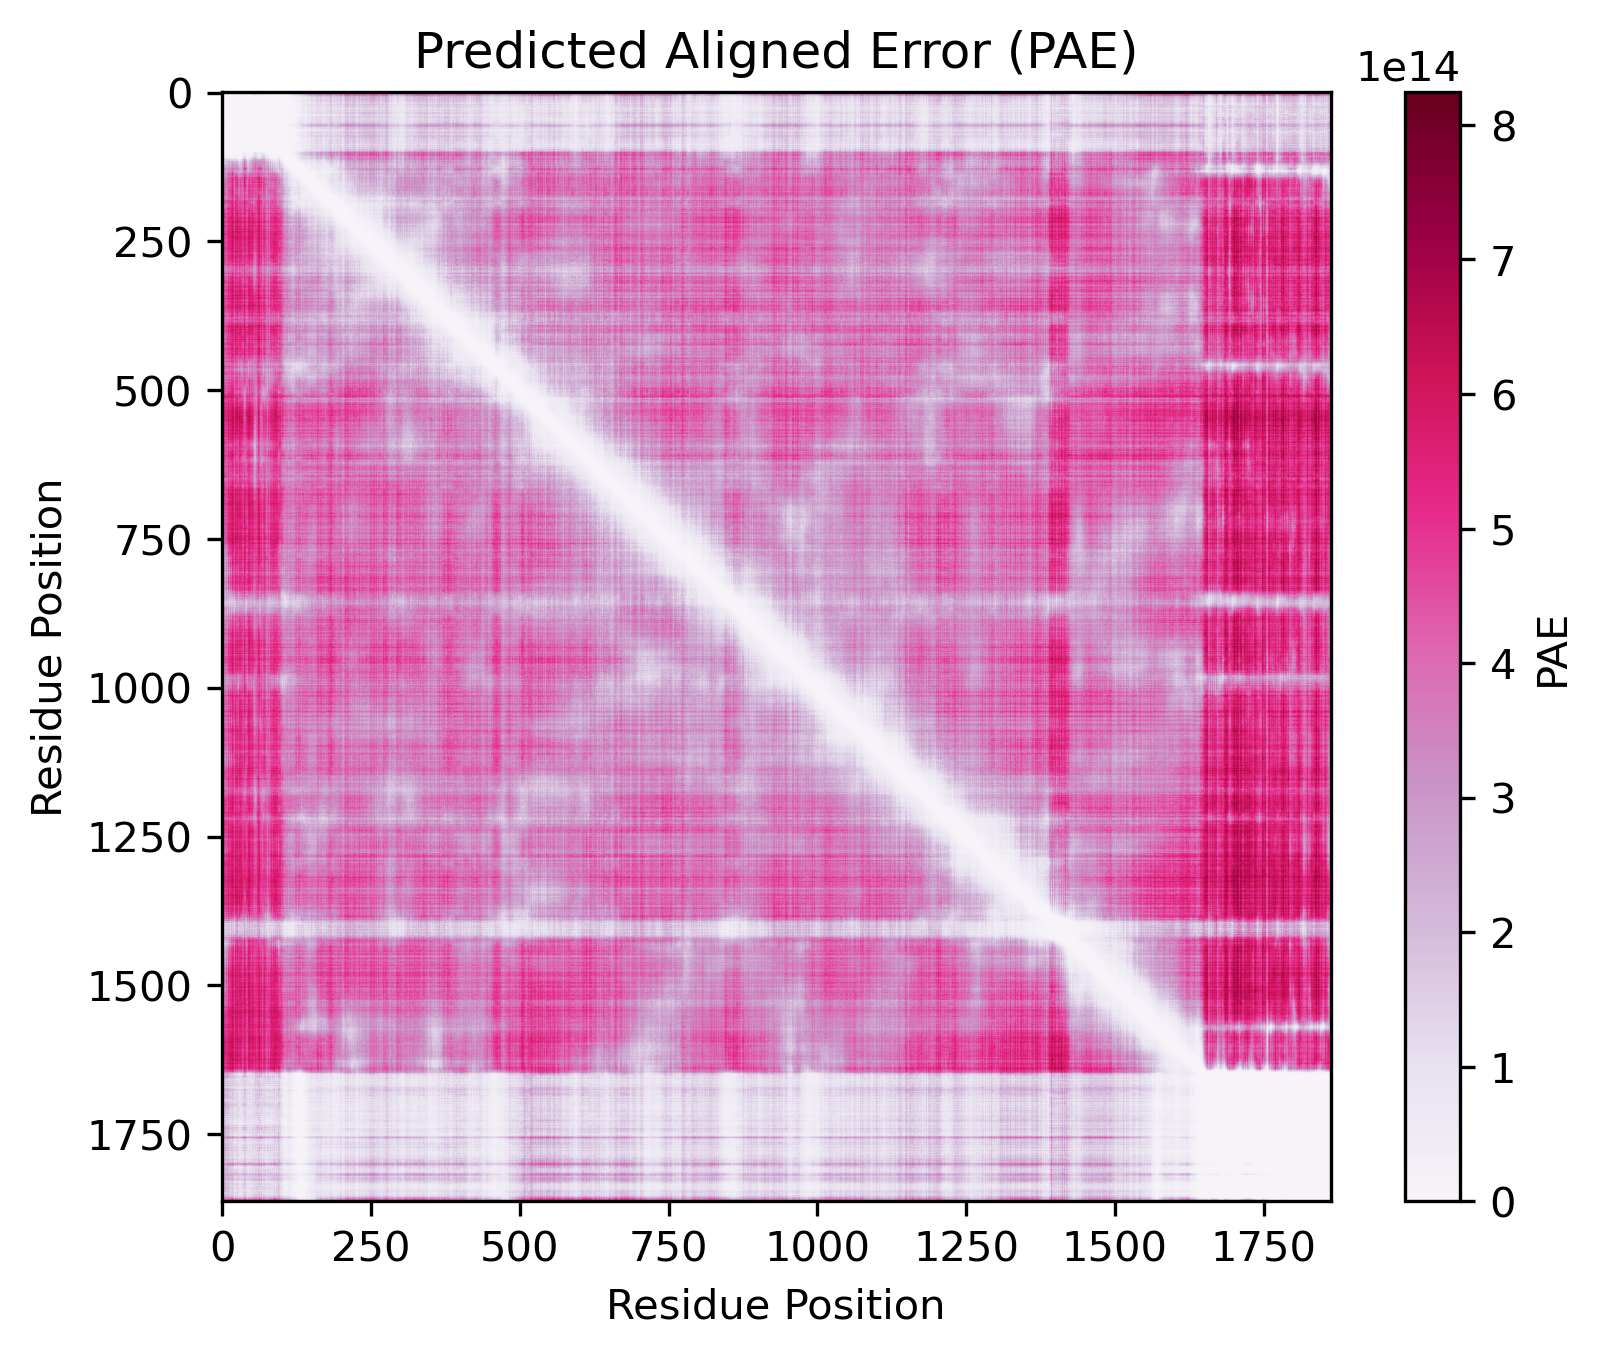

In [127]:
plt.figure(dpi=300)
plt.imshow(pae_matrix**10, cmap="PuRd")
plt.colorbar(label="PAE")
plt.title("Predicted Aligned Error (PAE)")
plt.xlabel("Residue Position")
plt.ylabel("Residue Position")
plt.show()

Pearson correlation: 0.3453 (p-value: 0.0000e+00)
Spearman correlation: 0.2494 (p-value: 0.0000e+00)


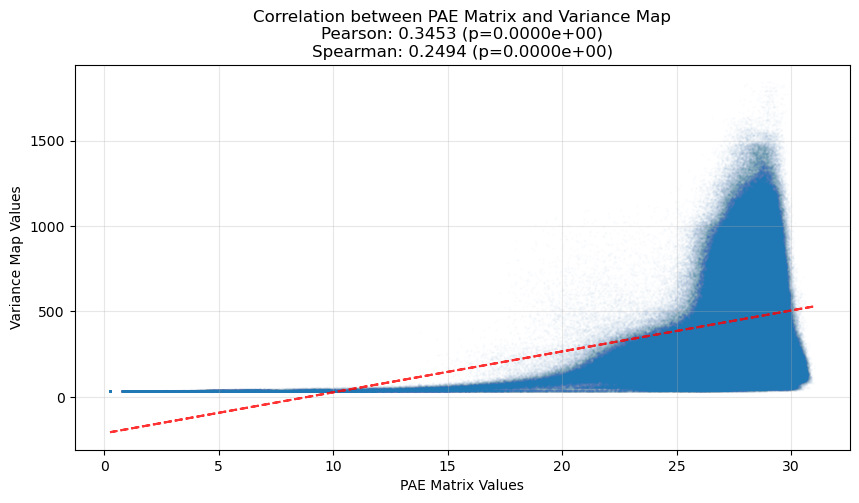


Interpretation: There is a moderate positive correlation between PAE matrix and variance map values.


In [132]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np


# Test correlation between pae_matrix and variance_map
if pae_matrix is not None and 'variance_map' in locals():
    # Flatten both matrices for correlation analysis
    pae_flat = pae_matrix.flatten()
    variance_flat = variance_map.flatten()
    
    # Calculate Pearson correlation
    pearson_corr, pearson_p = scipy.stats.pearsonr(pae_flat, variance_flat)
    
    # Calculate Spearman correlation (rank-based)
    spearman_corr, spearman_p = scipy.stats.spearmanr(pae_flat, variance_flat)
    
    print(f"Pearson correlation: {pearson_corr:.4f} (p-value: {pearson_p:.4e})")
    print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4e})")
    
    # Create scatter plot
    plt.figure(figsize=(10, 5))
    plt.scatter(pae_flat, variance_flat, alpha=0.01, s=1)
    # plt.hist2d(pae_flat, variance_flat, bins=100, cmap='viridis', density=True)
    plt.xlabel('PAE Matrix Values')
    plt.ylabel('Variance Map Values')
    plt.title(f'Correlation between PAE Matrix and Variance Map\nPearson: {pearson_corr:.4f} (p={pearson_p:.4e})\nSpearman: {spearman_corr:.4f} (p={spearman_p:.4e})')
    
    # Add trend line
    z = np.polyfit(pae_flat, variance_flat, 1)
    p = np.poly1d(z)
    plt.plot(pae_flat, p(pae_flat), "r--", alpha=0.8)
    
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Print interpretation
    if abs(pearson_corr) > 0.7:
        strength = "strong"
    elif abs(pearson_corr) > 0.3:
        strength = "moderate"
    else:
        strength = "weak"
    
    direction = "positive" if pearson_corr > 0 else "negative"
    print(f"\nInterpretation: There is a {strength} {direction} correlation between PAE matrix and variance map values.")
    
else:
    print("Cannot test correlation: pae_matrix or variance_map not available")


## AlphaFold embeddings

In [21]:
base_dir = os.path.expanduser("~/projects/data/colabfold")
npy_files = glob.glob(os.path.join(base_dir,
                                   "ENST00000357654",
                                   "**",
                                #  "*_single_repr_*_model_1_*.npy"
                                 "*_single_repr_*.npy"
                                # "*_pair_repr_*_model_*.npy"
                                   ),
                       recursive=True)
print(len(npy_files),"files found") 
npy_files

535 files found


['/home/schilder/projects/data/colabfold/ENST00000357654/results/ENSP00000350283_REF_single_repr_rank_005_alphafold2_ptm_model_4_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/results/ENSP00000350283_871P_L_1038E_G_1183K_R_1613S_G_single_repr_rank_002_alphafold2_ptm_model_2_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/results/ENSP00000350283_871P_L_1038E_G_1183K_R_1613S_G_single_repr_rank_004_alphafold2_ptm_model_3_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/results/ENSP00000350283_REF_single_repr_rank_001_alphafold2_ptm_model_2_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/results/ENSP00000350283_REF_single_repr_rank_002_alphafold2_ptm_model_1_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/results/ENSP00000350283_REF_single_repr_rank_003_alphafold2_ptm_model_5_seed_000.npy',
 '/home/schilder/projects/data/colabfold/ENST00000357654/results/ENSP00000350283_R

In [66]:
import re

af2_meta = pd.DataFrame({'protein_id': [os.path.basename(x).split("_")[0] for x in npy_files],
 'sample_id': [os.path.basename(x).split("_single")[0].split("_", 1)[1] for x in npy_files],
 'model_id': [re.search(r'model_(\d+)', os.path.basename(x)).group(1) for x in npy_files],
 'model_rank': [re.search(r'rank_(\d+)', os.path.basename(x)).group(1) for x in npy_files],
 'model_seed': [re.search(r'seed_(\d+)', os.path.basename(x)).group(1) for x in npy_files],
 'file':npy_files
 }
af2_meta.loc[:,"edit_distance"] = (af2_meta["sample_id"].str.count("_")+1)/2
af2_meta.loc[af2_meta["sample_id"]=="REF","edit_distance"] = 0
 )
af2_meta.head()

,protein_id,sample_id,model_id,model_rank,model_seed,file
0,ENSP00000350283,REF,4,005,000,/home/schilder/projects/data/colabfold/ENST000...
1,ENSP00000350283,871P_L_1038E_G_1183K_R_1613S_G,2,002,000,/home/schilder/projects/data/colabfold/ENST000...
2,ENSP00000350283,871P_L_1038E_G_1183K_R_1613S_G,3,004,000,/home/schilder/projects/data/colabfold/ENST000...
3,ENSP00000350283,REF,2,001,000,/home/schilder/projects/data/colabfold/ENST000...
4,ENSP00000350283,REF,1,002,000,/home/schilder/projects/data/colabfold/ENST000...


In [37]:
# Load all embeddings
embeddings = []
for npy_file in tqdm(npy_files, desc="Loading embeddings"):
    embedding = np.load(npy_file)
    # embedding = embedding.mean(axis=1).mean(axis=1)
    embeddings.append(embedding)

# Convert to numpy array
print("Converting to numpy array")
embeddings_array = np.array(embeddings)
print(f"Loaded {len(embeddings)} embeddings with shape: {embeddings_array.shape}")

# # Option to either flatten embeddings or take mean across sequence dimension
use_mean_embedding = True  # Set to False to flatten instead

if use_mean_embedding:
    # Take mean across sequence dimension (axis=1)
    # Each embedding is (seq_length, 128), we take mean to get (128,)
    embeddings_processed = np.mean(embeddings_array, axis=1)
    print(f"Mean embeddings shape: {embeddings_processed.shape}")
else:
    # Reshape embeddings for UMAP (flatten each embedding)
    # Each embedding is (seq_length, 256), we flatten to (seq_length * 256)
    embeddings_processed = embeddings_array.reshape(embeddings_array.shape[0], -1)
    print(f"Flattened embeddings shape: {embeddings_processed.shape}")



Loading embeddings:   0%|          | 0/535 [00:00<?, ?it/s]

Loading embeddings: 100%|██████████| 535/535 [00:00<00:00, 2086.90it/s]


Converting to numpy array
Loaded 535 embeddings with shape: (535, 1863, 256)
Mean embeddings shape: (535, 256)


In [38]:
from sklearn.preprocessing import StandardScaler
# Standardize the data
print("Standardizing data")
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_processed)
print(f"Scaled embeddings shape: {embeddings_scaled.shape}")

Standardizing data
Scaled embeddings shape: (535, 256)


In [67]:
# Subset embeddings_scaled by indices where model_id == 1
model_1_indices = af2_meta[af2_meta['model_id'] == "1"].index
embeddings_scaled_model_1 = embeddings_scaled[model_1_indices]
print(f"Subset embeddings for model_id=1: {embeddings_scaled_model_1.shape}")


Subset embeddings for model_id=1: (107, 256)


In [ ]:
import umap
import matplotlib.pyplot as plt

# Apply UMAP
print("Running UMAP") 

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_2d = reducer.fit_transform(embeddings_scaled[model_1_indices])


Running UMAP


/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Creating visualization


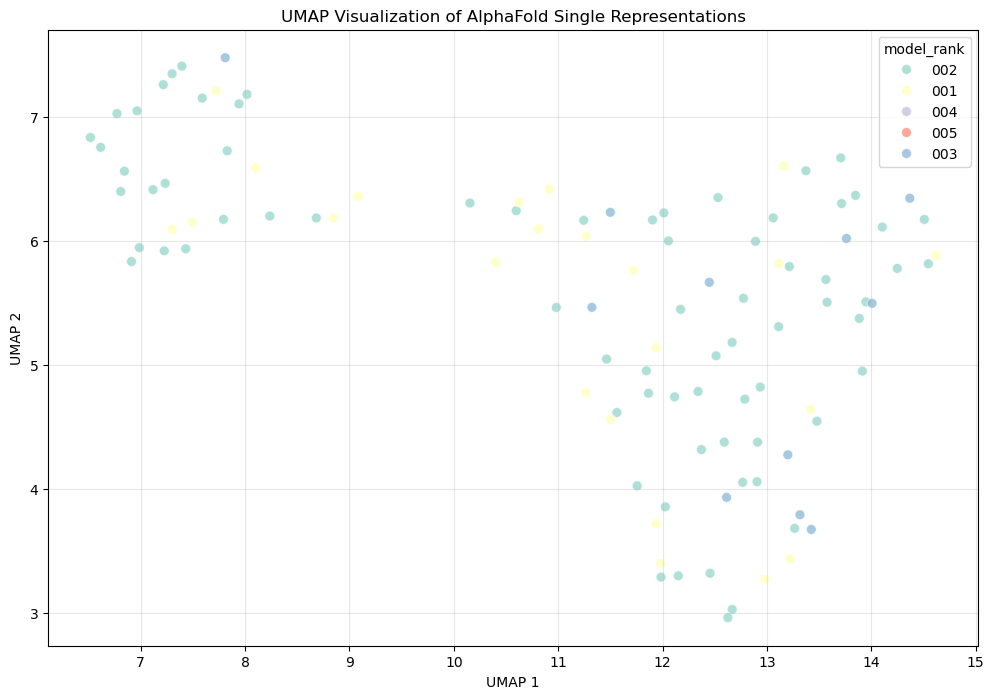

In [80]:
af2_meta.loc[model_1_indices, "umap_1"] = embeddings_2d[:, 0]
af2_meta.loc[model_1_indices, "umap_2"] = embeddings_2d[:, 1]

# Create visualization
print("Creating visualization")
plt.figure(figsize=(12, 8))
sns.scatterplot(data=af2_meta.sort_values(by=["sample_id","model_id", "model_rank"]), 
                x="umap_1", y="umap_2", 
                hue="model_rank", 
                palette="Set3",
                alpha=0.7, s=50)
plt.title('UMAP Visualization of AlphaFold Single Representations')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)
plt.show() 

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Create the base scatter plot
fig = px.scatter(af2_meta.sort_values(by=["sample_id","model_id", "model_rank"]), 
                 x="umap_1", y="umap_2", 
                 color="edit_distance", 
                 hover_data=["protein_id", "sample_id", "model_rank", "model_seed"],
                 title="UMAP Visualization of AlphaFold Single Representations")

# Add red diamond markers for REF samples
ref_data = af2_meta[af2_meta["sample_id"] == "REF"]
fig.add_trace(go.Scatter(
    x=ref_data["umap_1"],
    y=ref_data["umap_2"],
    mode='markers',
    marker=dict(
        symbol='diamond',
        size=10,
        color='rgba(255,0,0,0)',  # Transparent red (no fill)
        line=dict(width=2, color='black')
    ),
    name='REF<br>samples',
    showlegend=True,
    hoverinfo='skip'
))

# Make the colorbar shorter and anchor to bottom
fig.update_layout(
    coloraxis_colorbar=dict(
        len=0.6,  # Reduce colorbar length to 60% of default
        yanchor="bottom",
        y=0.0,
        title=dict(text="edit_distance".replace("_", "<br>"))
    )
)

fig.show()